In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==============================================================================
# 0. INSTALAÇÕES E IMPORTAÇÕES
# ==============================================================================
!pip install optuna xgboost -q

import os
import gc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb

from scipy.stats import skew, kurtosis
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Configuração para reprodutibilidade
SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING) # Reduzir verbosidade do Optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# 1. FUNÇÕES DE PRÉ-PROCESSAMENTO (FEATURE ENGINEERING)
# ==============================================================================
def extract_features(X_3d):
    """
    Transforma janelas (N, 125, 6) em atributos estatísticos (N, 36).
    Extrai: Média, Desvio Padrão, Mínimo, Máximo, Skewness e Kurtosis para cada eixo.
    """
    f_mean = np.mean(X_3d, axis=1)
    f_std = np.std(X_3d, axis=1)
    f_min = np.min(X_3d, axis=1)
    f_max = np.max(X_3d, axis=1)
    f_skew = skew(X_3d, axis=1)
    f_kurt = kurtosis(X_3d, axis=1)

    # Empilha tudo horizontalmente
    return np.hstack([f_mean, f_std, f_min, f_max, f_skew, f_kurt])

def flatten_data(X_3d):
    """Achata os dados de (N, 125, 6) para (N, 750) - Cenario Raw."""
    return X_3d.reshape(X_3d.shape[0], -1)


In [ ]:
# ==============================================================================
# 2. FUNÇÕES DE VALIDAÇÃO (BOOTSTRAP) E OTIMIZAÇÃO (OPTUNA)
# ==============================================================================
def bootstrap_eval(model, X_test, y_test, n_iterations=30):
    """Validação usando reamostragem estatística com reposição."""
    n_size = len(y_test)
    f1_scores = []
    acc_scores = []

    for _ in range(n_iterations):
        # Amostragem com reposição
        indices = np.random.choice(n_size, size=n_size, replace=True)
        X_sample = X_test[indices]
        y_sample = y_test[indices]

        preds = model.predict(X_sample)
        f1_scores.append(f1_score(y_sample, preds, average='macro'))
        acc_scores.append(accuracy_score(y_sample, preds))

    mean_f1 = np.mean(f1_scores)
    mean_acc = np.mean(acc_scores)

    return mean_f1, mean_acc

def optimize_xgboost(X_t, y_t, X_v, y_v, n_trials=15):
    """Otimização Bayesiana de hiperparâmetros com Optuna."""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'tree_method': 'hist', # Usar histogramas para treinar muito mais rápido
            'random_state': SEED,
            'n_jobs': -1
        }

        model = xgb.XGBClassifier(**params)
        model.fit(X_t, y_t)
        preds = model.predict(X_v)

        return f1_score(y_v, preds, average='macro')

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params


In [ ]:
# ==============================================================================
# 3. CARREGAMENTO DOS DADOS
# ==============================================================================
DATASET_PATH = "/content/drive/MyDrive/2026/ic/npz_files/sbhar_v2.npz"

print("Carregando os dados...")
data = np.load(DATASET_PATH)
X_train_full = data['X_train']
y_train_full = data['y_train']

X_val_full = data['X_val']
y_val_full = data['y_val']

X_test_full = data['X_test']
y_test_full = data['y_test']

print(f"Treino: {X_train_full.shape} | Validação: {X_val_full.shape} | Teste: {X_test_full.shape}")


Carregando os dados...
Treino: (7233, 125, 6) | Validação: (801, 125, 6) | Teste: (3275, 125, 6)



Iniciando Cenário: 1. Raw Data - Sem Optuna
   -> Usando parâmetros Default.
   -> Treinando modelo final...
   -> Rodando Bootstrap (30 iterações)...
   [Bootstrap] F1-Mean: 0.7805 | Acc-Mean: 0.8963


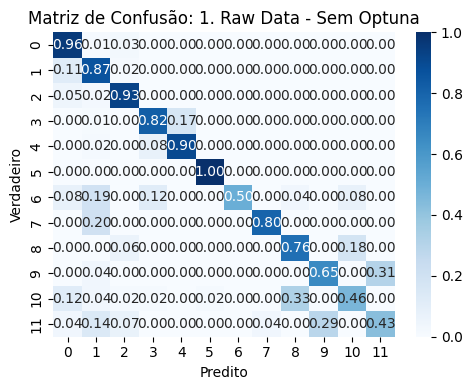


Iniciando Cenário: 2. Raw Data - Com Optuna
   -> Buscando melhores parâmetros com Optuna...
   -> Melhores parâmetros: {'n_estimators': 124, 'max_depth': 3, 'learning_rate': 0.24416353825990306, 'subsample': 0.7502475445612373, 'colsample_bytree': 0.7148668020389564, 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}
   -> Treinando modelo final...
   -> Rodando Bootstrap (30 iterações)...
   [Bootstrap] F1-Mean: 0.7879 | Acc-Mean: 0.8961


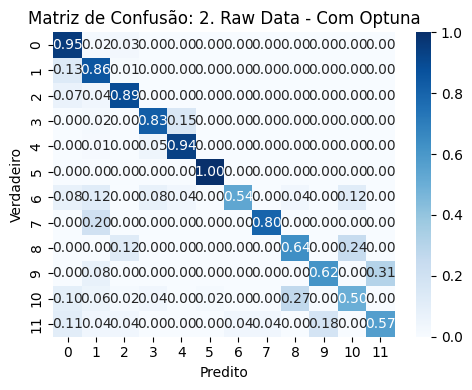


Iniciando Cenário: 3. Feature Engineering - Sem Optuna
   -> Usando parâmetros Default.
   -> Treinando modelo final...
   -> Rodando Bootstrap (30 iterações)...
   [Bootstrap] F1-Mean: 0.7825 | Acc-Mean: 0.8726


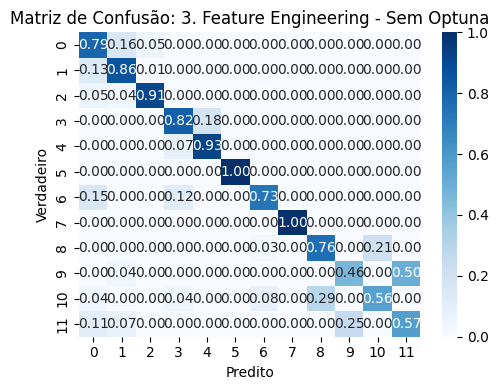


Iniciando Cenário: 4. Feature Engineering - Com Optuna
   -> Buscando melhores parâmetros com Optuna...
   -> Melhores parâmetros: {'n_estimators': 257, 'max_depth': 4, 'learning_rate': 0.19300259134492362, 'subsample': 0.7921120970536362, 'colsample_bytree': 0.6884748274880661, 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}
   -> Treinando modelo final...
   -> Rodando Bootstrap (30 iterações)...
   [Bootstrap] F1-Mean: 0.8092 | Acc-Mean: 0.8847


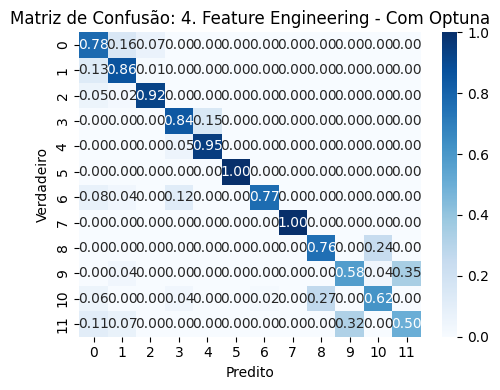

In [ ]:
# ==============================================================================
# 4. EXECUÇÃO DOS 4 CENÁRIOS
# ==============================================================================
from sklearn.metrics import confusion_matrix

scenarios = [
    {"name": "1. Raw Data - Sem Optuna", "is_fe": False, "is_opt": False},
    {"name": "2. Raw Data - Com Optuna", "is_fe": False, "is_opt": True},
    {"name": "3. Feature Engineering - Sem Optuna", "is_fe": True, "is_opt": False},
    {"name": "4. Feature Engineering - Com Optuna", "is_fe": True, "is_opt": True}
]

results = []

for sc in scenarios:
    name = sc["name"]
    is_fe = sc["is_fe"]
    is_opt = sc["is_opt"]

    print(f"\n{'='*50}")
    print(f"Iniciando Cenário: {name}")
    print(f"{'='*50}")

    # A. Tratamento dos Dados (Feature Engineering ou Flatten)
    if is_fe:
        X_tr = extract_features(X_train_full)
        X_va = extract_features(X_val_full)
        X_te = extract_features(X_test_full)
    else:
        X_tr = flatten_data(X_train_full)
        X_va = flatten_data(X_val_full)
        X_te = flatten_data(X_test_full)

    # B. Otimização (Se aplicável)
    if is_opt:
        print("   -> Buscando melhores parâmetros com Optuna...")
        best_params = optimize_xgboost(X_tr, y_train_full, X_va, y_val_full, n_trials=15)
        best_params['tree_method'] = 'hist'
        best_params['random_state'] = SEED
        best_params['n_jobs'] = -1
        print(f"   -> Melhores parâmetros: {best_params}")
    else:
        print("   -> Usando parâmetros Default.")
        best_params = {'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1}

    # C. Treinamento Final (juntando treino e validação para o modelo final)
    print("   -> Treinando modelo final...")
    X_tr_final = np.vstack([X_tr, X_va])
    y_tr_final = np.concatenate([y_train_full, y_val_full])

    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr_final, y_tr_final)

    # D. Validação Bootstrap
    print("   -> Rodando Bootstrap (30 iterações)...")
    boot_f1, boot_acc = bootstrap_eval(model, X_te, y_test_full)
    print(f"   [Bootstrap] F1-Mean: {boot_f1:.4f} | Acc-Mean: {boot_acc:.4f}")

    results.append({
        "Scenario": name,
        "F1_Mean": boot_f1,
        "Acc_Mean": boot_acc
    })

    # E. Matriz de Confusão do Teste
    preds = model.predict(X_te)
    cm = confusion_matrix(y_test_full, preds, normalize='true')
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
    plt.title(f'Matriz de Confusão: {name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    plt.tight_layout()
    plt.show()

    # F. Gerenciamento de Memória agressivo
    del X_tr, X_va, X_te, X_tr_final, y_tr_final, model, preds
    gc.collect()




=== RELATÓRIO FINAL (SBHAR - XGBoost) ===
                           Scenario  F1_Mean  Acc_Mean
           1. Raw Data - Sem Optuna 0.780522  0.896316
           2. Raw Data - Com Optuna 0.787936  0.896061
3. Feature Engineering - Sem Optuna 0.782537  0.872611
4. Feature Engineering - Com Optuna 0.809236  0.884672


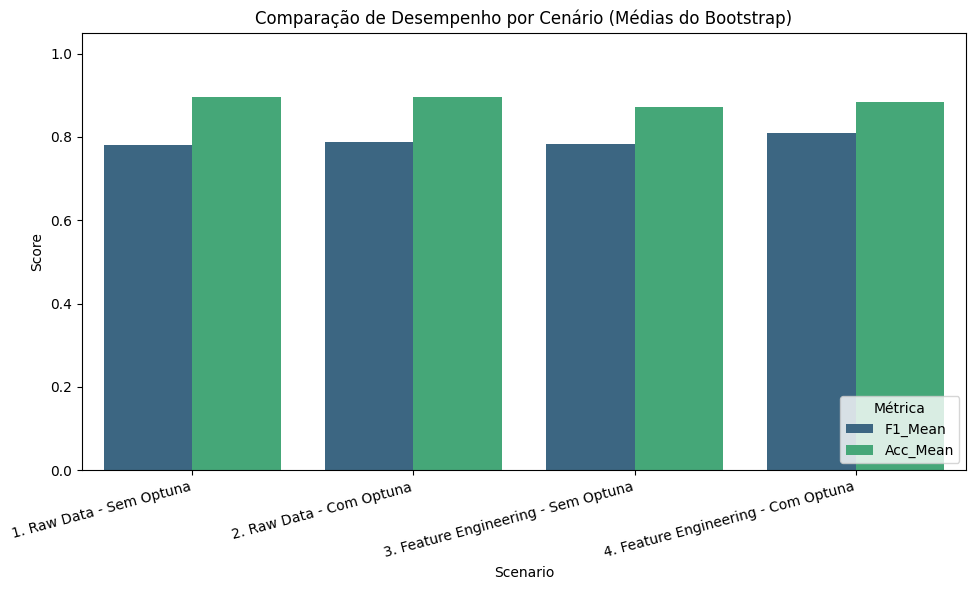

In [ ]:
# ==============================================================================
# 5. RELATÓRIO FINAL
# ==============================================================================
df_res = pd.DataFrame(results)
print("\n\n" + "="*50)
print("=== RELATÓRIO FINAL (SBHAR - XGBoost) ===")
print("="*50)
print(df_res.to_string(index=False))

# Preparando dados para o histograma agrupado
df_melt = df_res.melt(id_vars='Scenario', value_vars=['F1_Mean', 'Acc_Mean'],
                      var_name='Metrica', value_name='Valor')

# Plotagem
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melt, x='Scenario', y='Valor', hue='Metrica', palette='viridis')

plt.title('Comparação de Desempenho por Cenário (Médias do Bootstrap)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Métrica', loc='lower right')
plt.tight_layout()
plt.show()
